In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *

from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
mouse = 25
day = 24

# good examples include 
#mice = [25, 25, 26, 27, 29, 28]
#days = [25, 24, 18, 26, 23, 25]

25 24
optimal travel lag is 6.856856856856858 cm
there are 33 non_grid and non_spatial_cells
there are 24 grid_cells
there are 24 non grid spatial cells
there are 9 non spatial cells
there are 12 speed cells
there are 69 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'PAR']
for the grid cells the unique locations are ['ENTm1' 'ENTm2' 'PAR' 'VISpl5']
unique brain regions ['ENTm1' 'ENTm2' 'PAR' 'VISp5' 'VISpl5']
there are 43 MEC cells
there are 8 PARA cells
there are 0 PRE cells
there are 18 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 69 all cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 26.056554362780552
Not merging labels 0 and 2 with distance 15.404161697700657
Not merging labels 1 and 2 with distance 10.792785914877891
Found 4 modules with HDBSCAN for mouse 25 day 24
for e

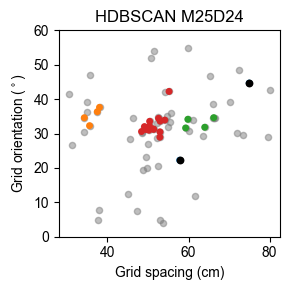

for module 0, there are 4 cells with average spacing 36.35747355941553
for module 1, there are 4 cells with average spacing 62.324193394413754
for module 2, there are 14 cells with average spacing 51.540367833089405
module 0 contains cells from ['VISpl5']
module 2 contains cells from ['ENTm2' 'VISpl5']
module 1 contains cells from ['ENTm1' 'ENTm2']
25 24
for module 0, there are 4 cells
for module 2, there are 14 cells
for module 1, there are 4 cells


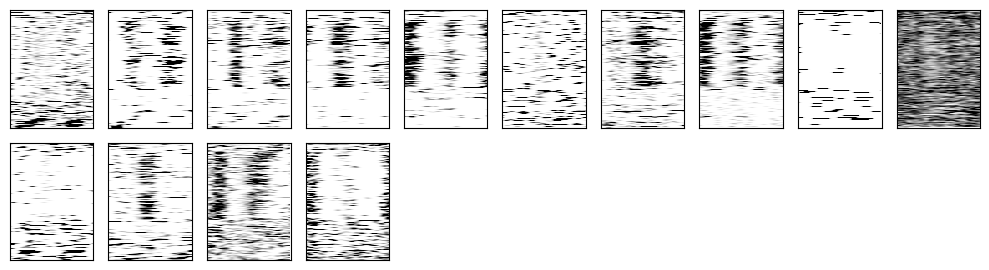

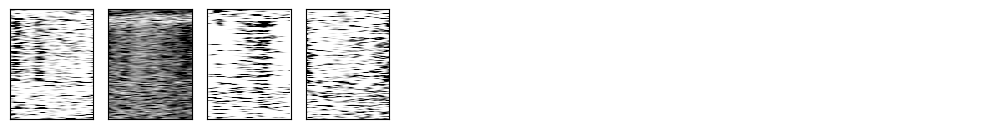

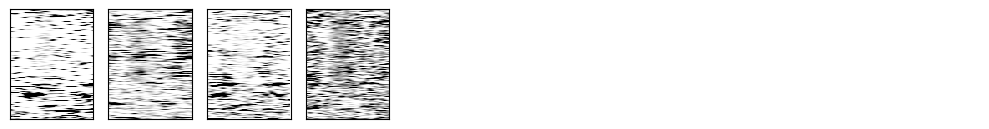

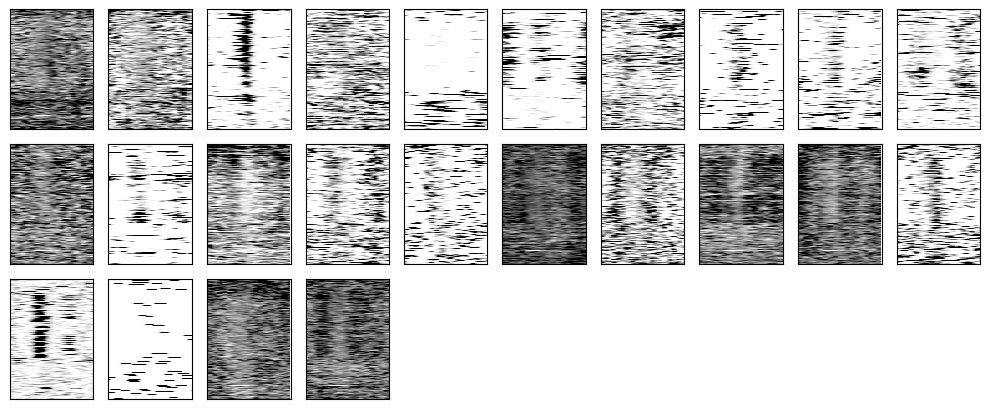

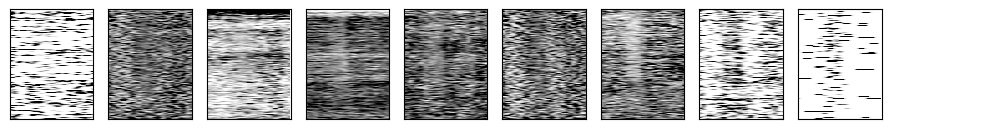

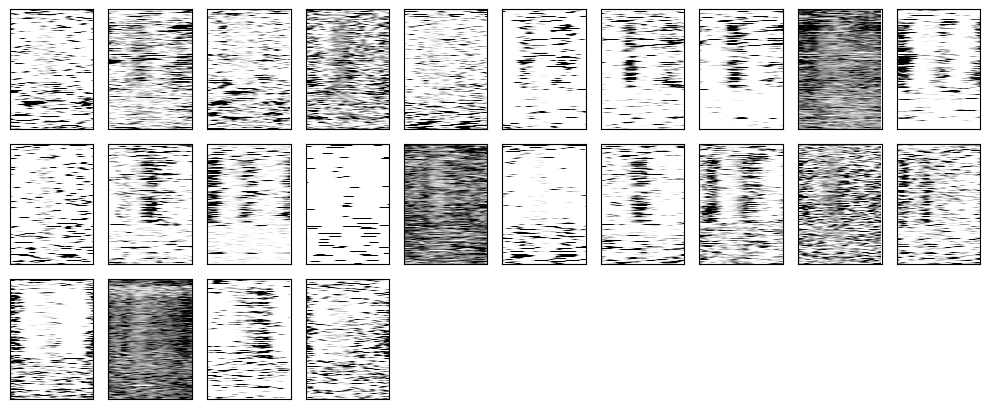

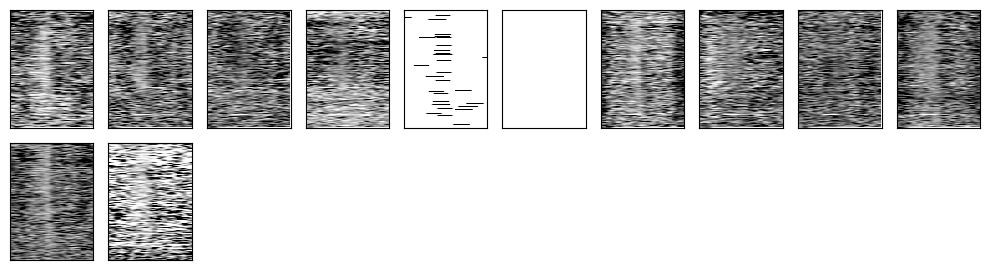

In [3]:
gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95) # subset
rc, rsc, vr_ns = cell_classification_vr(mouse, day)
_, _, _, _, _, _, _, all_by_anatomy = cell_classification_anatomy(mouse,day)
g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3, 
                                                figpath=fig_path, curate_with_vr=False, curate_with_brain_region=True) # create grid modules using HDBSCAN    

plot_grid_modules_rate_maps(gcs, g_m_ids, g_m_cluster_ids, mouse, day, figpath=fig_path)

# we now have cluster ids classified into modules, non grid spatial cells and non spatial cells 
# as defined by activity in the open field
g_m_cluster_ids = sorted(g_m_cluster_ids, key=len, reverse=True) 
cluster_ids_by_group = []
cluster_ids_by_group.extend(g_m_cluster_ids) # grid cells by module [0,1,2...]
cluster_ids_by_group.append(ngs.cluster_id.values.tolist()) # non grid spatial [-4]
cluster_ids_by_group.append(ns.cluster_id.values.tolist()) # non spatial cells [-3]
cluster_ids_by_group.append(gcs.cluster_id.values.tolist()) # all grid cells [-2]
cluster_ids_by_group.append(sc.cluster_id.values.tolist()) # speed cells [-1]

for m, cluster_ids in enumerate(cluster_ids_by_group):
    plot_vr_rate_maps(mouse, day, cluster_ids, label=f'{m}', figpath=fig_path)

#plot_vr_rate_maps(mouse, day, rc.cluster_id.values, label=f'ramp_cells', figpath=fig_path)
#plot_vr_rate_maps(mouse, day, rsc.cluster_id.values, label=f'speed_ramp_cells', figpath=fig_path)

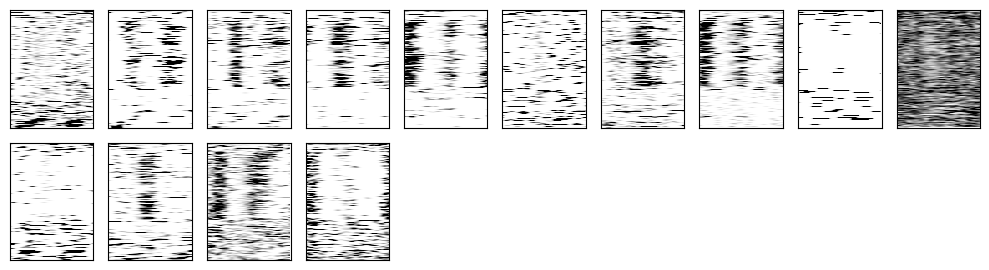

In [4]:
cluster_ids=cluster_ids_by_group[0]
tcs,tcs_time,_,_,_,_ = compute_vr_tcs(mouse, day)
ncols = 10
nrows = int(np.ceil(len(cluster_ids)/ncols))
fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=(10, 1.4*nrows), squeeze=False)
counter = 0
for j in range(nrows):
    for i in range(ncols):
        if counter<len(cluster_ids):
            index = cluster_ids[counter]
            plot_firing_rate_map(ax[j, i], 
                                zscore(tcs[index]),
                                bs=bs,
                                tl=tl,
                                p=95)
        else:
            ax[j, i].axis('off')
        counter+=1
        ax[j, i].set_xticks([])
        ax[j, i].set_yticks([])
        ax[j, i].xaxis.set_tick_params(labelbottom=False)
        ax[j, i].yaxis.set_tick_params(labelleft=False)
plt.tight_layout()
plt.show()

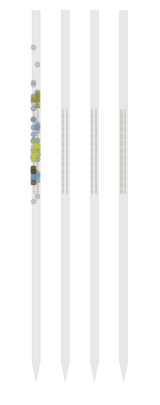

In [5]:
markers = ['x', '^', 's']
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(4, 5), squeeze=False)
plot_NP2_probe(ax[0,0], sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa', contacts_alpha=0.3)
ax[0,0].scatter(all_by_anatomy['probe_x'], all_by_anatomy['probe_y'], color='tab:grey', alpha=0.3, s=10)
ax[0,0].scatter(ngs['probe_x'], ngs['probe_y'], color='#6897CD', alpha=0.3, s=10)
m_colors = ['#CAC841', "#8F8D15", "#504F1B", "#E3E000", "#22220D"]
for m, cluster_ids in enumerate(g_m_cluster_ids):
    m_gcs = gcs[gcs.cluster_id.isin(cluster_ids)]
    ax[0,0].scatter(m_gcs['probe_x'], m_gcs['probe_y'], alpha=0.6, color=m_colors[m], marker=markers[m], s=10)
ax[0,0].set_xlim(-200, 1000)
ax[0,0].set_ylim(-300, 3000)
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/M{mouse}D{day}_probe.pdf',  bbox_inches='tight')
plt.show()

Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules


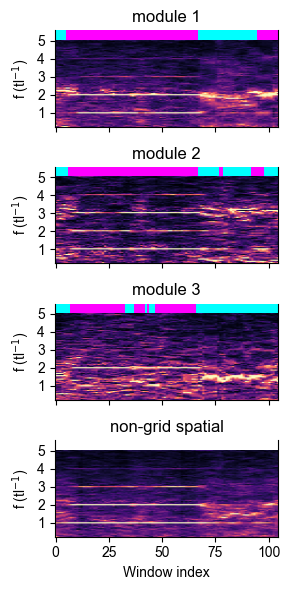

In [6]:


fig, ax = plt.subplots(nrows=len(g_m_cluster_ids)+1, ncols=1, figsize=(3, 6), squeeze=False, sharex=True)
peak_indices = [12, 28, 44, 60, 76]

for m in range(len(g_m_cluster_ids)):
    cluster_ids = g_m_cluster_ids[m]
    tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
    results = spectral_analysis(tcs_to_use, tl, bs=bs)
    spectrograms = results[3] 
    fvalid = results[5]

    S = spectrograms.mean(0)
    ax[m,0].set_title(f'module {m+1}')
    ax[m,0].imshow(S,origin='lower',aspect='auto',vmax=0.25,cmap='magma')
    max_peaks = np.argmax(S, axis=0)
    #ax[m,0].scatter(np.arange(S.shape[1]), max_peaks, color='#CAC841',s=3)
    ax[m,0].set_yticks(peak_indices, [1, 2, 3, 4, 5])
    ax[m,0].set_ylabel(r'f (tl$^{-1}$)')
    ax[m,0].spines['top'].set_visible(False)
    
    # Cluster labels: 1 if max at peak_indices_gm, else 0
    labels = np.isin(max_peaks, peak_indices).astype(int)
    ax[m,0].scatter(
        np.arange(S.shape[1]),
        np.full(S.shape[1], 81),  # y just above the top
        c=labels,
        cmap='cool',
        marker='s',
        s=50,
        vmin=0, 
        vmax=1,
        edgecolor='none',
        clip_on=True
    )

# Non-grid spatial
tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in ngs.cluster_id.values if cluster_id in tcs}
results = spectral_analysis(tcs_to_use, tl, bs=bs)
spectrograms = results[3] 
S = spectrograms.mean(0)

ax[-1,0].set_title(f'non-grid spatial')
ax[-1,0].imshow(S,origin='lower',aspect='auto',vmax=0.25,cmap='magma')
max_peaks = np.argmax(S, axis=0)
#ax[-1,0].scatter(np.arange(S.shape[1]), max_peaks, color='#6897CD',s=3)
ax[-1,0].set_yticks(peak_indices, [1, 2, 3, 4, 5])
ax[-1,0].set_ylabel(r'f (tl$^{-1}$)')
ax[-1,0].set_xlabel('Window index')
ax[-1,0].spines['top'].set_visible(False)
labels = np.isin(max_peaks, peak_indices).astype(int)
ax[-1,0].scatter(
    np.arange(S.shape[1]),
    np.full(S.shape[1], 81),  # y just above the top
    c=labels,
    cmap='cool',
    marker='s',
    vmin=0, 
    vmax=1,
    s=50,
    alpha=0,
    edgecolor='none',
    clip_on=True
)

plt.tight_layout()
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/M{mouse}D{day}_joint_spectrograms.pdf',  bbox_inches='tight')
plt.show()

In [7]:
for m in range(len(g_m_cluster_ids)):
    plot_individual_rate_maps_with_avg_based_on_task_anchoring(mouse, day,
                                                           cluster_ids_for_spectrogram=g_m_cluster_ids[0],
                                                           cluster_ids=g_m_cluster_ids[m], 
                                                           label=f'_module{m}_', 
                                                           figpath='/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/')
plot_individual_rate_maps_with_avg_based_on_task_anchoring(mouse, day,
                                                           cluster_ids_for_spectrogram=g_m_cluster_ids[0],
                                                           cluster_ids=ngs.cluster_id.values, 
                                                           label=f'ngs_', 
                                                           figpath='/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/')


Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules


In [8]:
bs_t=100
tcs, tcs_time, autocorrs, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse, day, bs_t=bs_t)
speed_in_time, dt_in_time, pos_in_time, trial_number_in_time, trial_type_in_time = get_time_binned_variables(mouse, day, bs_t=bs_t)

cluster_ids = []
cluster_ids.extend(g_m_cluster_ids[0]) # grid cells by module [0,1,2...]
cluster_ids.extend(g_m_cluster_ids[1]) # grid cells by module [0,1,2...]
cluster_ids.extend(g_m_cluster_ids[2]) # grid cells by module [0,1,2...]
#cluster_ids.extend(ngs.cluster_id.values.tolist()) # non grid spatial [-4]
#cluster_ids = all_by_anatomy['cluster_id'].values.tolist() # all cells
 
# decoding in time
clusters_tcs_time = {cluster_id: tcs_time[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs_time}
print(f'Number of clusters to decode: {len(clusters_tcs_time)}')

pos_in_time = np.array(pos_in_time) 
trial_number_in_time = np.array(trial_number_in_time)
dt_in_time = np.array(dt_in_time)
tns_to_decode_with = np.array(beh['trials']['number'])
tns_to_decode_with = tns_to_decode_with[tns_to_decode_with<=np.nanmax(trial_number_in_time)]
trial_types = np.array(beh['trials']['type'])

tns_to_decode = np.array(beh['trials']['number']) # decode all trials to visualise
tns_to_train = np.array(beh['trials']['number'][(np.isin(beh['trials']['type'], np.array(['b','nb']))) &
                                                (np.isin(beh['trials']['performance'], np.array(['hit'])))]) 
tns_to_train = np.array(beh['trials']['number'][(np.isin(beh['trials']['type'], np.array(['b','nb'])))]) 
tns_to_decode = tns_to_decode[tns_to_decode<=np.nanmax(trial_number_in_time)] # handles last ephys trials
tns_to_train = tns_to_train[tns_to_train<=np.nanmax(trial_number_in_time)] # handles last ephys trials

predictions_in_time, errors_in_time = cross_validate_decoder_time(clusters_tcs_time, 
                                                true_position=pos_in_time, 
                                                trial_numbers=trial_number_in_time, 
                                                tns_to_decode=tns_to_decode, 
                                                tns_to_train=tns_to_train, 
                                                tl=tl, bs=bs, train=0.9, n=10, verbose=False)

avg_predictions_in_time = [np.mean(np.stack(preds_n), axis=0) for preds_n in predictions_in_time]
avg_predictions_in_time = np.concatenate(avg_predictions_in_time).ravel()
avg_errors_in_time = [np.mean(np.stack(errors_n), axis=0) for errors_n in errors_in_time]
avg_errors_in_time = np.concatenate(avg_errors_in_time).ravel()

Number of clusters to decode: 22


Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules


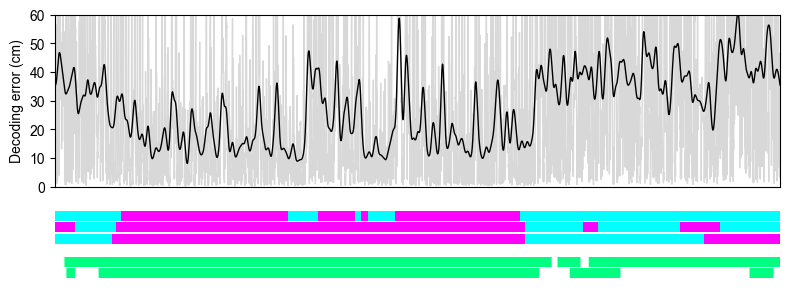

In [29]:
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# --- Top row: True vs Predicted Position ---
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 3), sharex=True, height_ratios=[1, 0.4])

# Time axis (in seconds)
time_axis = np.arange(len(pos_in_time))*(bs_t/1000)/60

def break_large_jumps(arr, threshold):
    arr = np.array(arr)
    diffs = np.abs(np.diff(arr))
    # Find indices where the jump exceeds the threshold
    jump_idx = np.where(diffs > threshold)[0] + 1
    arr_plot = arr.astype(float).copy()
    arr_plot[jump_idx] = np.nan
    return arr_plot

# --- Decoding Error: raw and smooth ---
smooth_error = gaussian_filter1d(avg_errors_in_time, sigma=40)
ax[0].plot(time_axis, avg_errors_in_time, label='Prediction Error (raw)', color='grey', alpha=0.3, linewidth=1)
ax[0].plot(time_axis, smooth_error, label='Prediction Error (smoothed)', color='black', linewidth=1)
ax[0].set_ylabel('Decoding error (cm)')
ax[0].set_ylim(0,60)

peak_indices = [12, 28, 44, 60, 76]

for m in range(len(g_m_cluster_ids)):
    cluster_ids = g_m_cluster_ids[m]
    tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
    results = spectral_analysis(tcs_to_use, tl, bs=bs)
    spectrograms = results[3] 
    fvalid = results[5]
    S = spectrograms.mean(0)
    max_peaks = np.argmax(S, axis=0)
    labels = np.isin(max_peaks, peak_indices).astype(int)

    tc = tcs[g_m_cluster_ids[0][0]]
    tc = tc[:last_ephys_bin] # only want bins with ephys data in it
    trial_labels = get_kmeans_spatial_labels(tc, labels, bs=bs, tl=tl) # reuse kmeans function to get the labels based on the task anchoring
    # get time binned labels
    labels_in_time = trial_number_in_time.copy()
    for label, tn in zip(trial_labels, np.unique(trial_number_in_time)):
        labels_in_time[trial_number_in_time == tn] = label
    
    ax[-1].scatter(time_axis, np.ones(len(labels_in_time))*m, 
                   c=labels_in_time, cmap='cool', marker='s', s=50, vmin=0, vmax=1, edgecolor='none',clip_on=True)
    
    ax[-1].spines['top'].set_visible(False)
    ax[-1].spines['left'].set_visible(False)
    ax[-1].spines['bottom'].set_visible(False)
    ax[-1].spines['right'].set_visible(False)
    ax[-1].set_ylim(-3.5,2.5)
    ax[-1].set_yticks([])
    ax[-1].set_xticks([])



performance = np.array(beh['trials']['performance'])
trial_types = np.array(beh['trials']['type'])
trial_numbers = np.array(beh['trials']['number'])

# make performance in time
b_performance_in_time = np.zeros(len(pos_in_time)); b_performance_in_time[:] = np.nan
nb_performance_in_time = np.zeros(len(pos_in_time)); nb_performance_in_time[:] = np.nan
for i, tn in enumerate(trial_number_in_time):
    if tn in trial_numbers[(trial_types == 'b') & (performance == 'hit')]:
        b_performance_in_time[i] = 1
    elif tn in trial_numbers[(trial_types == 'nb') & (performance == 'hit')]:
        nb_performance_in_time[i] = 1


# make performance in time
b_performance_in_time = np.zeros(len(pos_in_time)); b_performance_in_time[:] = np.nan
nb_performance_in_time = np.zeros(len(pos_in_time)); nb_performance_in_time[:] = np.nan
b_streak = 0
nb_streak = 0
for i, tn in enumerate(trial_number_in_time):
    if tn in trial_numbers[(trial_types == 'b') & (performance == 'hit')]:
        b_streak += 1
    elif tn in trial_numbers[(trial_types == 'nb') & (performance == 'hit')]:
        nb_streak += 1
    elif tn in trial_numbers[(trial_types == 'b') & (performance != 'hit')]:
        b_streak = 0
    elif tn in trial_numbers[(trial_types == 'nb') & (performance != 'hit')]:
        nb_streak = 0
    if b_streak >= 150:
        b_performance_in_time[i] = 1
    if nb_streak >= 150:
        nb_performance_in_time[i] = 1
ax[-1].scatter(time_axis, np.ones(len(b_performance_in_time)) -3, 
               c=b_performance_in_time, cmap='winter', marker='|', s=50, vmin=0, vmax=1, edgecolor='none',clip_on=True)
ax[-1].scatter(time_axis, np.ones(len(nb_performance_in_time)) -4, 
               c=nb_performance_in_time, cmap='winter', marker='|', s=50, vmin=0, vmax=1, edgecolor='none',clip_on=True)

ax[0].set_xlim(18.5,22)
ax[0].set_xlim(0, 30)
plt.tight_layout()
fig.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/M{mouse}D{day}_decoding_error.pdf', bbox_inches='tight')
plt.show()

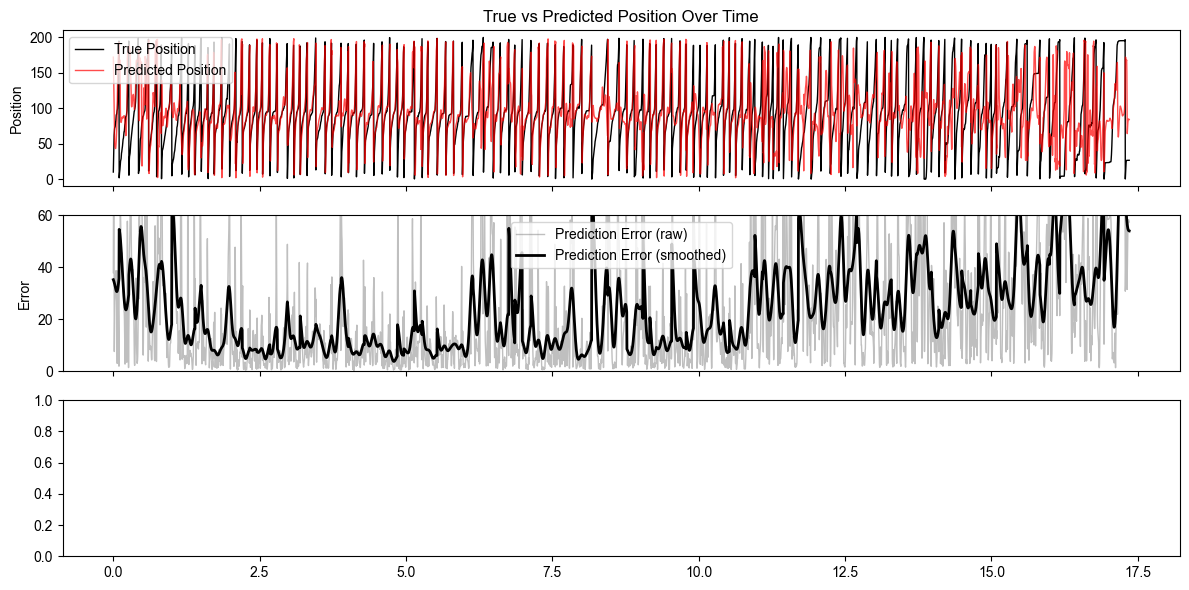

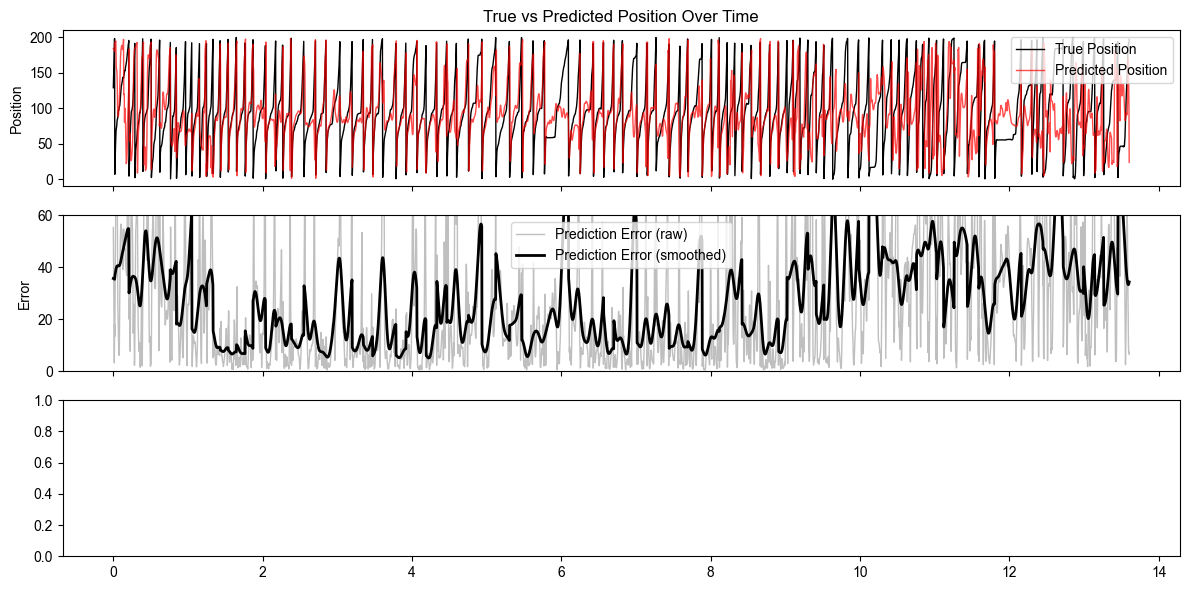

In [ ]:
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

for tt in ['b', 'nb']:
    # --- Top row: True vs Predicted Position ---
    fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 6), sharex=True)

    # Time axis (in seconds)
    time_axis = np.arange(len(pos_in_time[trial_type_in_time==tt]))*(bs_t/1000)/60

    ax[0].plot(time_axis, pos_in_time[trial_type_in_time==tt], label='True Position', color='black', linewidth=1)
    ax[0].plot(time_axis, avg_predictions_in_time[trial_type_in_time==tt], label='Predicted Position', color='red', alpha=0.7, linewidth=1)
    ax[0].set_ylabel('Position')
    ax[0].set_title('True vs Predicted Position Over Time')
    ax[0].legend()

    # --- Decoding Error: raw and smooth ---
    smooth_error = gaussian_filter1d(avg_errors_in_time, sigma=10)
    ax[1].plot(time_axis, avg_errors_in_time[trial_type_in_time==tt], label='Prediction Error (raw)', color='grey', alpha=0.5, linewidth=1)
    ax[1].plot(time_axis, smooth_error[trial_type_in_time==tt], label='Prediction Error (smoothed)', color='black', linewidth=2)
    ax[1].set_ylabel('Error')
    ax[1].legend()
    ax[1].set_ylim(0,60)
    plt.tight_layout()
    plt.show()

In [145]:
cluster_ids = []
cluster_ids.extend(g_m_cluster_ids[0]) # grid cells by module [0,1,2...]
cluster_ids.extend(g_m_cluster_ids[1]) # grid cells by module [0,1,2...]
cluster_ids.extend(g_m_cluster_ids[2]) # grid cells by module [0,1,2...]
#cluster_ids.extend(ngs.cluster_id.values.tolist()) # non grid spatial [-4]
plot_decoding(mouse, day, cluster_ids=cluster_ids, label='all_cells', 
              figpath='/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/')

225


plot the spectrograms and the maximal frequency at each time point

Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules


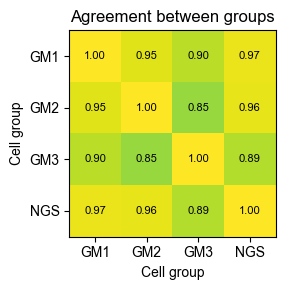

In [24]:
group_names = ['GM' + str(i+1) for i in range(len(g_m_cluster_ids))] + ['NGS']
group_labels = []
group_spectrograms = []
for m in range(len(g_m_cluster_ids)):
    cluster_ids = g_m_cluster_ids[m]
    tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
    results = spectral_analysis(tcs_to_use, tl, bs=bs)
    spectrograms = results[3]
    fvalid = results[5]

    S = spectrograms.mean(0)
    kmeans = KMeans(n_clusters=2, random_state=0, n_init='auto')
    labels = kmeans.fit_predict(S.T)
    group_labels.append(labels)
    group_spectrograms.append(S)
tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in ngs.cluster_id.values if cluster_id in tcs}
results = spectral_analysis(tcs_to_use, tl, bs=bs)
spectrograms = results[3] 
S = spectrograms.mean(0)
kmeans = KMeans(n_clusters=2, random_state=0, n_init='auto')
labels = kmeans.fit_predict(S.T)
group_labels.append(labels)
group_spectrograms.append(S)

# calculate agreement between groups
agreements = np.zeros((len(group_spectrograms), len(group_spectrograms)))
for i, m in enumerate(range(len(group_spectrograms))):
    for j, n in enumerate(range(len(group_spectrograms))):
        agreements[i, j] = np.sum(group_labels[i] == group_labels[j]) / len(group_labels[i])

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3, 3), squeeze=False)

ax[0,0].imshow(agreements, cmap='viridis', vmin=0, vmax=1)
# offset the x and y ticks to be the group names
ax[0,0].set_xticks(np.arange(len(group_names)))
ax[0,0].set_yticks(np.arange(len(group_names)))
ax[0,0].set_xticklabels(group_names)
ax[0,0].set_yticklabels(group_names)
ax[0,0].set_xlabel('Cell group')
ax[0,0].set_ylabel('Cell group')

ax[0,0].set_title('Agreement between groups')   
# add agreeement values to the cells
for i in range(len(group_names)):
    for j in range(len(group_names)):
        ax[0,0].text(j, i, f'{agreements[i, j]:.2f}', ha='center', va='center', color='black', fontsize=8)
plt.tight_layout()    
plt.show()

In [ ]:
for m, cluster_ids in enumerate(g_m_cluster_ids):
    plot_individual_rate_maps_with_avg_based_on_task_anchoring(mouse, day, cluster_ids=cluster_ids, label=f'_module{m}_', figpath='/Users/harryclark/Documents/figs/rate_maps_by_grid_module/')
    plot_individual_rate_maps_with_avg_k_means_grouped_spectrogram(mouse, day, cluster_ids=cluster_ids, label=f'_module{m}_', figpath='/Users/harryclark/Documents/figs/rate_maps_by_grid_module/')
    plot_individual_rate_maps_with_avg(mouse, day, cluster_ids=cluster_ids, label=f'_module{m}_', figpath='/Users/harryclark/Documents/figs/rate_maps_by_grid_module/')
plot_individual_rate_maps_with_avg_k_means_grouped_spectrogram(mouse, day, cluster_ids=ngs.cluster_id.values, label=f'_NGS_', figpath='/Users/harryclark/Documents/figs/rate_maps_by_grid_module/')


In [ ]:
def get_task_anchored_labels_in_time(mouse, day, cluster_ids_for_spectrogram):
    tcs, tcs_time, autocorrs, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse, day, apply_zscore=False) # recompute tcs without z-scoring to use in the spectrogram
    tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids_for_spectrogram if cluster_id in tcs}
    results = spectral_analysis(tcs_to_use, tl, bs=bs)
    spectrograms = results[3] 
    S = spectrograms.mean(0)
    max_peaks = np.argmax(S, axis=0)
    labels = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int) # these are the peaks that correspond to the task anchoring
    trial_labels = get_kmeans_spatial_labels(tcs[cluster_ids_for_spectrogram[0]], labels, bs=bs, tl=tl) # reuse kmeans function to get the labels based on the task anchoring

    last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units = 'ms').index[-1]

    # time binned variables for later
    ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units = 's')
    speed_in_time = beh['S'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)
    dt_in_time = beh['travel'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)-((beh['trial_number'][0]-1)*tl)
    time_vals = np.arange(0, len(speed_in_time)*(time_bs/1000),time_bs/1000) # secs
    pos_in_time = dt_in_time%tl
    trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

    trial_number_in_time = pd.Series(np.array(trial_number_in_time)).fillna(method='ffill').fillna(method='bfill').to_numpy()
    trial_labels_trial_numbers = np.arange(trial_number_in_time[0], len(trial_labels)+trial_number_in_time[0], 1)
    trial_labels_in_time = np.zeros(len(trial_number_in_time), dtype=int)
    assert len(trial_labels) == len(trial_labels_trial_numbers), f'len(trial_labels)={len(trial_labels)} != len(trial_labels_trial_numbers)={len(trial_labels_trial_numbers)}'

    for i, tn in enumerate(trial_number_in_time.astype(int)):
        trial_labels_in_time[i] = trial_labels[np.where(trial_labels_trial_numbers == tn)[0][0]].astype(int)
    
    return trial_labels_in_time



In [ ]:
# we want to compare the firing rate changes between task anchoring and task independent firing according to grid module 1
cluster_ids_for_spectrogram = g_m_cluster_ids[0] # use the first grid module for the spectrogram

tcs, tcs_time, autocorrs, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse, day, apply_zscore=False) # recompute tcs without z-scoring to use in the spectrogram
tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids_for_spectrogram if cluster_id in tcs}
results = spectral_analysis(tcs_to_use, tl, bs=bs)
spectrograms = results[3] 
S = spectrograms.mean(0)
max_peaks = np.argmax(S, axis=0)
labels = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int) # these are the peaks that correspond to the task anchoring
trial_labels = get_kmeans_spatial_labels(tcs[cluster_ids_for_spectrogram[0]], labels, bs=bs, tl=tl) # reuse kmeans function to get the labels based on the task anchoring

last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units = 'ms').index[-1]

# time binned variables for later
ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units = 's')
speed_in_time = beh['S'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)
dt_in_time = beh['travel'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)-((beh['trial_number'][0]-1)*tl)
time_vals = np.arange(0, len(speed_in_time)*(time_bs/1000),time_bs/1000) # secs
pos_in_time = dt_in_time%tl
trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

trial_number_in_time = pd.Series(np.array(trial_number_in_time)).fillna(method='ffill').fillna(method='bfill').to_numpy()
trial_labels_trial_numbers = np.arange(trial_number_in_time[0], len(trial_labels)+trial_number_in_time[0], 1)
trial_labels_in_time = np.zeros(len(trial_number_in_time), dtype=int)
assert len(trial_labels) == len(trial_labels_trial_numbers), f'len(trial_labels)={len(trial_labels)} != len(trial_labels_trial_numbers)={len(trial_labels_trial_numbers)}'

for i, tn in enumerate(trial_number_in_time.astype(int)):
    trial_labels_in_time[i] = trial_labels[np.where(trial_labels_trial_numbers == tn)[0][0]].astype(int)


